In [1]:
import numpy as np
from scipy import fft
import scipy as sp
from matplotlib import pyplot as plt


%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


In digital signal processing, *sampling* refers to the process of converting an time-continuous signal into a time-discrete signal.

Mathematically, a continuous signal $x(t)$ is sampled through a multiplication with an
impulse train $\delta_T(t)$ - also referred to as Dirac comb - of infitite length:
 

$$x[n] = x(t) \delta_T (t) = \sum\limits_{n=-\infty}^{\infty} x(n T) \delta (t-nT)$$

----

## Dirac Comb

The Dirac comb is a periodic function: 

$$
\delta(t-nT) = \delta(t-nT+T)
$$

The following plot shows a Dirac comb for $ T = 0.01$:

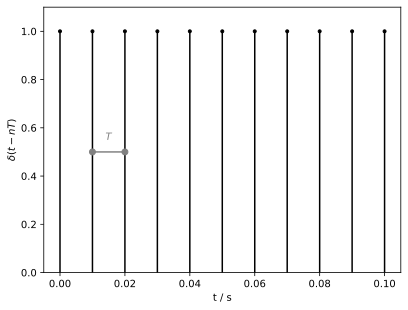

In [2]:
fig,ax = plt.subplots()

fs = 10                      # time distance between pulses
Fs = 1000                  # sampling frequency, used for discretizing the system

t = np.linspace(0, 1/fs, 101) # time range to consider
T=10
comb = np.zeros_like(t)
comb[::int(T)] = 2     # Comb becomes T every T*Fs samples
ax.stem(t, comb-1, 'k', markerfmt='k.', basefmt=" ")
ax.set_ylim([0,1.1])
ax.set_xlabel('t / s')
ax.set_ylabel('$\delta(t-nT)$');

plt.plot([0.01, 0.02],[0.5,0.5],'gray',markevery=[0,-1], marker='o')
plt.annotate("$T$", xy=( 0.014,0.55),color='gray');

## Fourier Series of the Dirac Comb

This impulse train can be expressed as a Fourier series with the Dirichlet-kernel (which is related to the sinc function):

$$\delta_T = \frac{1}{T}   \sum_{n=-\infty}^{\infty} e^{j 2 \pi n \frac{t}{T}}$$

The figure below shows how this series converges towards an impulse train:

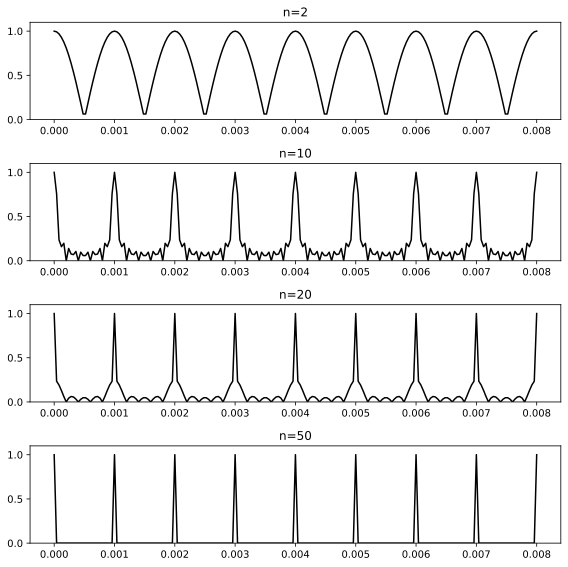

In [45]:
 
x = np.linspace(-8*np.pi, 8*np.pi, num=201)
px = np.linspace(0, 0.008, 201)

plt.figure(figsize=(8, 8));

for idx, n in enumerate([2, 10, 20, 50]):

    plt.subplot(4, 1, idx+1)
    plt.ylim([0,1.1])
    plt.plot(px, abs(sp.special.diric(x, n)),'k')

    plt.title('n={}'.format(n))


plt.tight_layout() 
plt.show()


----

## Fourier Transform of the Dirac Comb

The Fourier transform of a time-domain impulse train is 
a frequency-domain impulse train:

$$\begin{eqnarray}
\mathcal{F}(\delta_T)&= &\int_{-\infty}^{\infty} \delta_T e^{-j 2 \pi f t}dt \\
&=& \sum_{n=-\infty}^{\infty} \int_{-\infty}^{\infty} \delta(t-nT) e^{-j 2 \pi f t}dt \\
\end{eqnarray}$$


The Fourier transform of the shifted impulse is a complex exponential: 


$$\begin{eqnarray}
\mathcal{F}(\delta_T)&=& {\sum\limits_{n = -\infty}^{\infty} e^{-j 2 \pi n T f}} \\
\delta_F&=&  \delta(f - \frac{n}{T})
\end{eqnarray}$$

 

----

With the above equation represents the Fourier sieries of a Dirac comb.
**The Fourier transform of the Dirac comb in the time domain is a Dirac comb in the frequency domain with:**

$$
\Delta f = \frac{1}{T}
$$



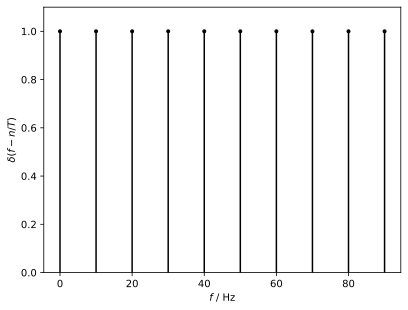

In [44]:
fig,ax = plt.subplots()

f = np.linspace(0, 90, 100) # time range to consider

comb = np.zeros_like(f)

comb[np.arange(0,100,11)] = 2  

ax.stem(f, comb-1, 'k', markerfmt='k.', basefmt=" ")
ax.set_ylim([0,1.1])
ax.set_xlabel('$f$ / Hz')
ax.set_ylabel('$\delta(f-n/T)$');

----

# Fourier Transform of the Sampled Signal



**The convolution with the Dirac comb in the frequency domain results in a periodic spectrum.**



$$X[i] = \frac{1}{T}  + \sum\limits_{n=-\infty}^{\infty}   X(\omega -n \omega_s)$$

From the DFT section we know that our DFT $X[n]$ is defined between $-f_s/2$ and $f_s/2$. According to the convolution theorem, a multiplication of two signals in the time domain is equivalent to a convolution in the frequency domain:




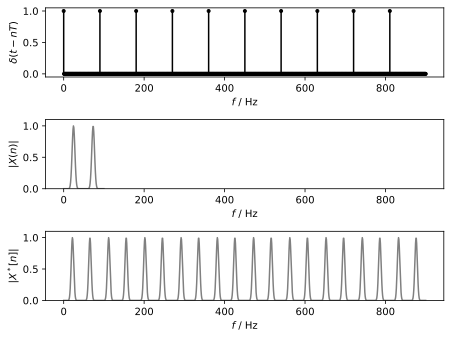

In [69]:
fig = plt.figure()

f = np.linspace(0, 900, 1000) # time range to consider

comb = np.zeros_like(f)

comb[np.arange(0,1000,100)] = 1 

ax = plt.subplot(3,1,1)
ax.stem(f, comb, 'k', markerfmt='k.', basefmt=" ") 
ax.set_xlabel('$f$ / Hz')
ax.set_ylabel('$\delta(t-nT)$');

ss = np.linspace(0,100,100)
spec = np.pow(np.sin(65*t),20)

ax3 = plt.subplot(3,1,2)
ax3.plot(f, comb,'white') 
ax3.plot(ss,spec[0:-1],'gray')
ax3.set_ylim([0,1.1])
ax3.set_xlabel('$f$ / Hz')
ax3.set_ylabel('$|X(n)|$');

c = np.convolve(comb,spec)

ax2 = plt.subplot(3,1,3)
ax2.plot(f, c[0:1000], 'gray')
ax2.set_ylim([0,1.1])
ax2.set_xlabel('$f$ / Hz')
ax2.set_ylabel('$|X^*[n]|$');

fig.tight_layout(pad=1)
